# Experimentation and Box plots

1. Importing libraries

In [98]:
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.preprocessing import MinMaxScaler
%matplotlib inline
from sklearn.model_selection import train_test_split

2. Load the NSL-KDD Data

In [99]:
col_names = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes",
    "land","wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root","num_file_creations",
    "num_shells","num_access_files","num_outbound_cmds","is_host_login","is_guest_login",
    "count","srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate",
    "same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty"
]
data = pd.read_csv("..\data\\nsl-kdd\KDDTrain+.txt",names=col_names)
data.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


3. Encoding the Categorical Values

In [100]:
data=pd.get_dummies(data,columns=["protocol_type","service","flag"])

In [101]:
scaler=MinMaxScaler()
num_cols=data.drop(["label","difficulty"],axis=1).columns
data[num_cols]=scaler.fit_transform(data[num_cols])

In [102]:
data["label"]=data["label"].apply(lambda x: 0 if x=="normal" else 1)

In [103]:
data.head()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,0.0,3.558064e-07,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,1.057999e-07,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0.0,1.681203e-07,6.223962e-06,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,1.442067e-07,3.206260e-07,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


4. EDA using Boxplots
- Boxplots, also known as box-and-whisker plots.
- These are useful for identifying outliers and understanding the skewness of the data.
- Also used when comparing multiple groups or visualizing the distribution of a single variable.

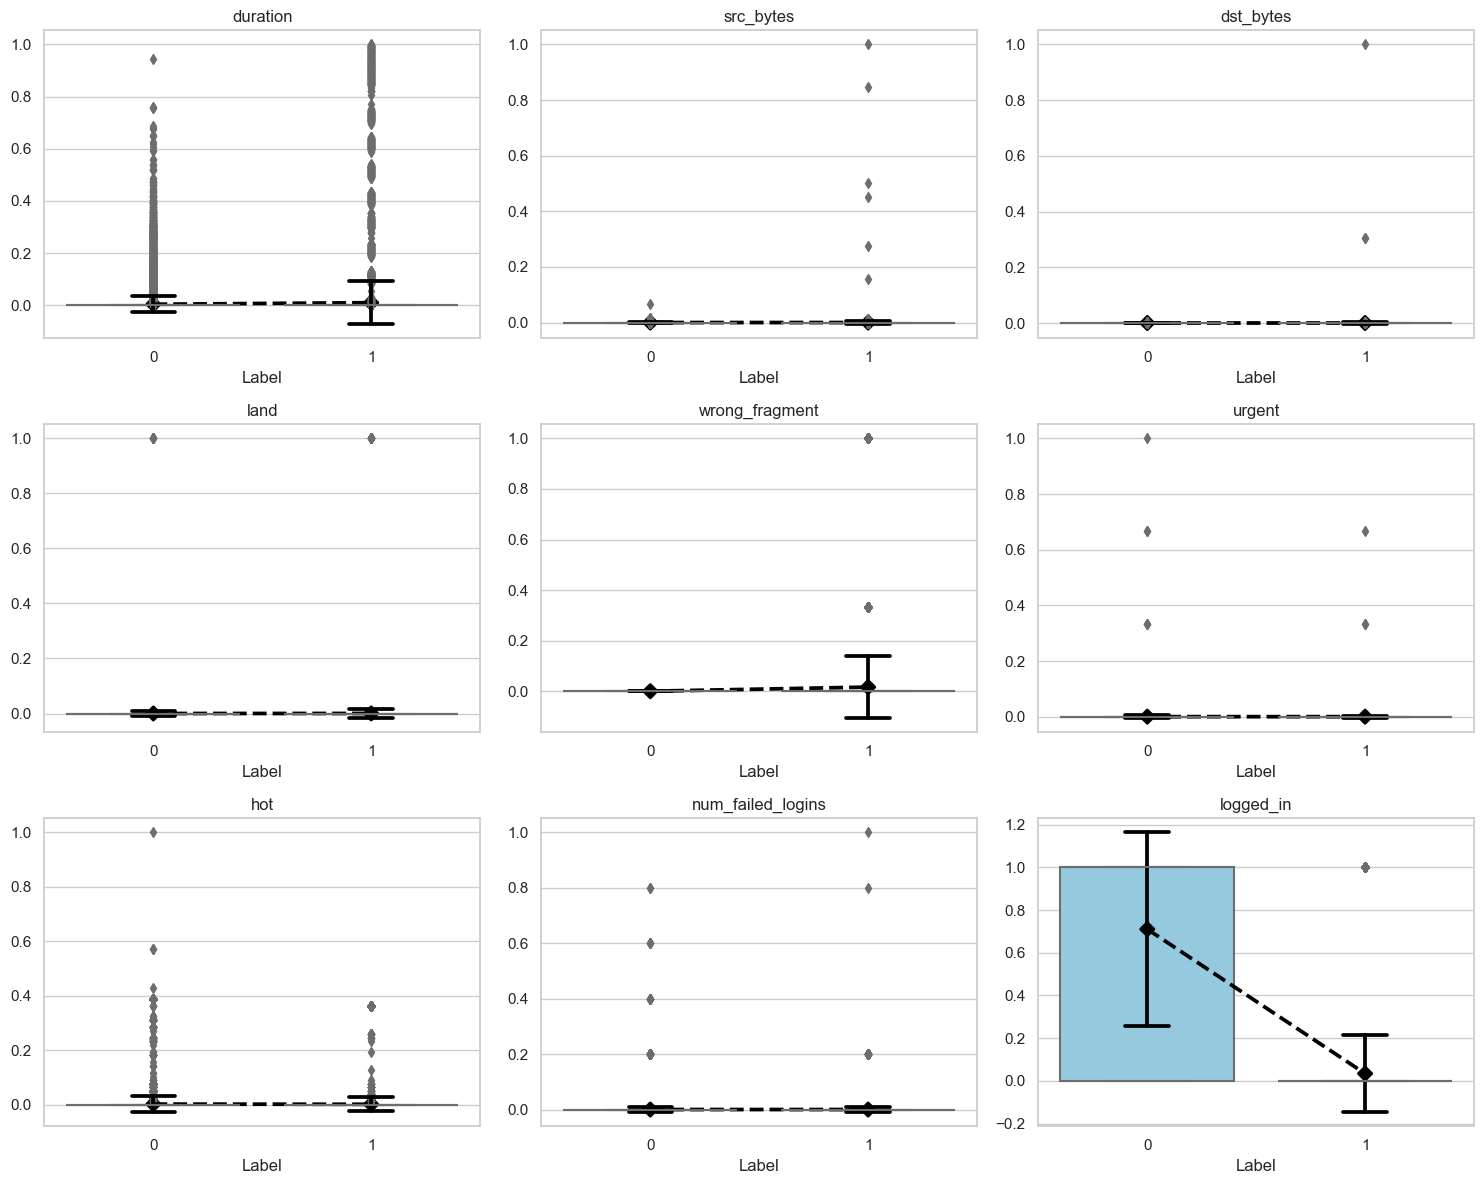

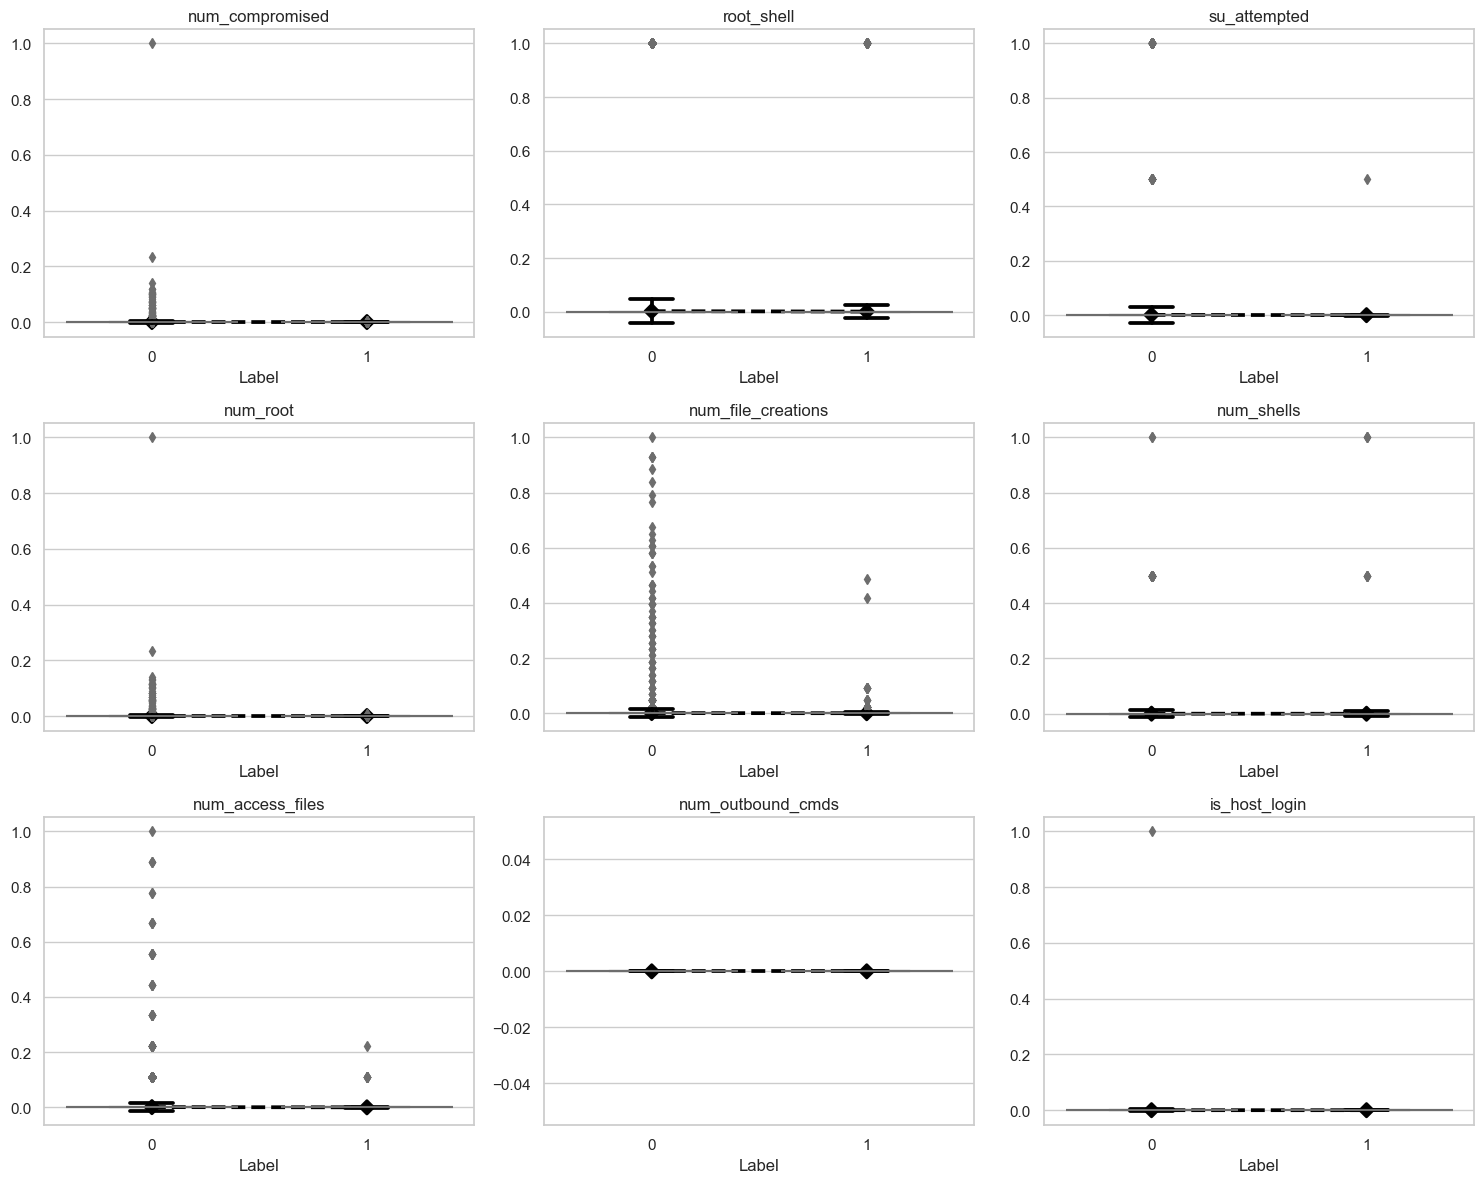

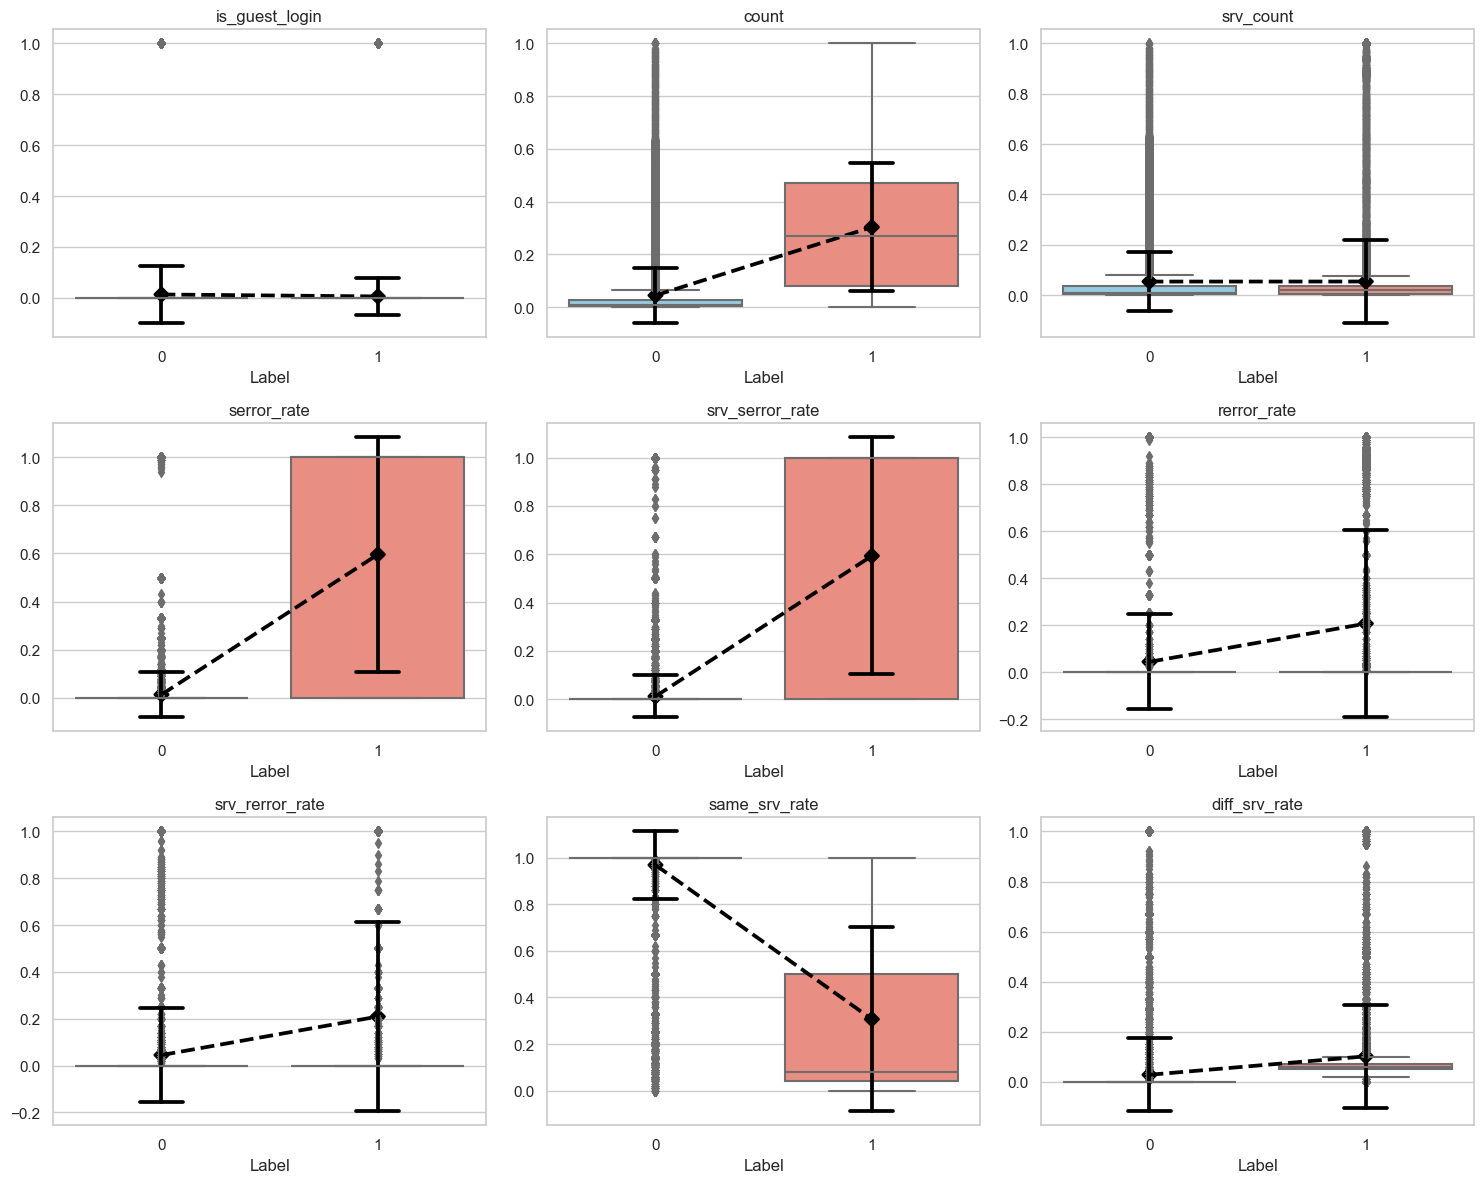

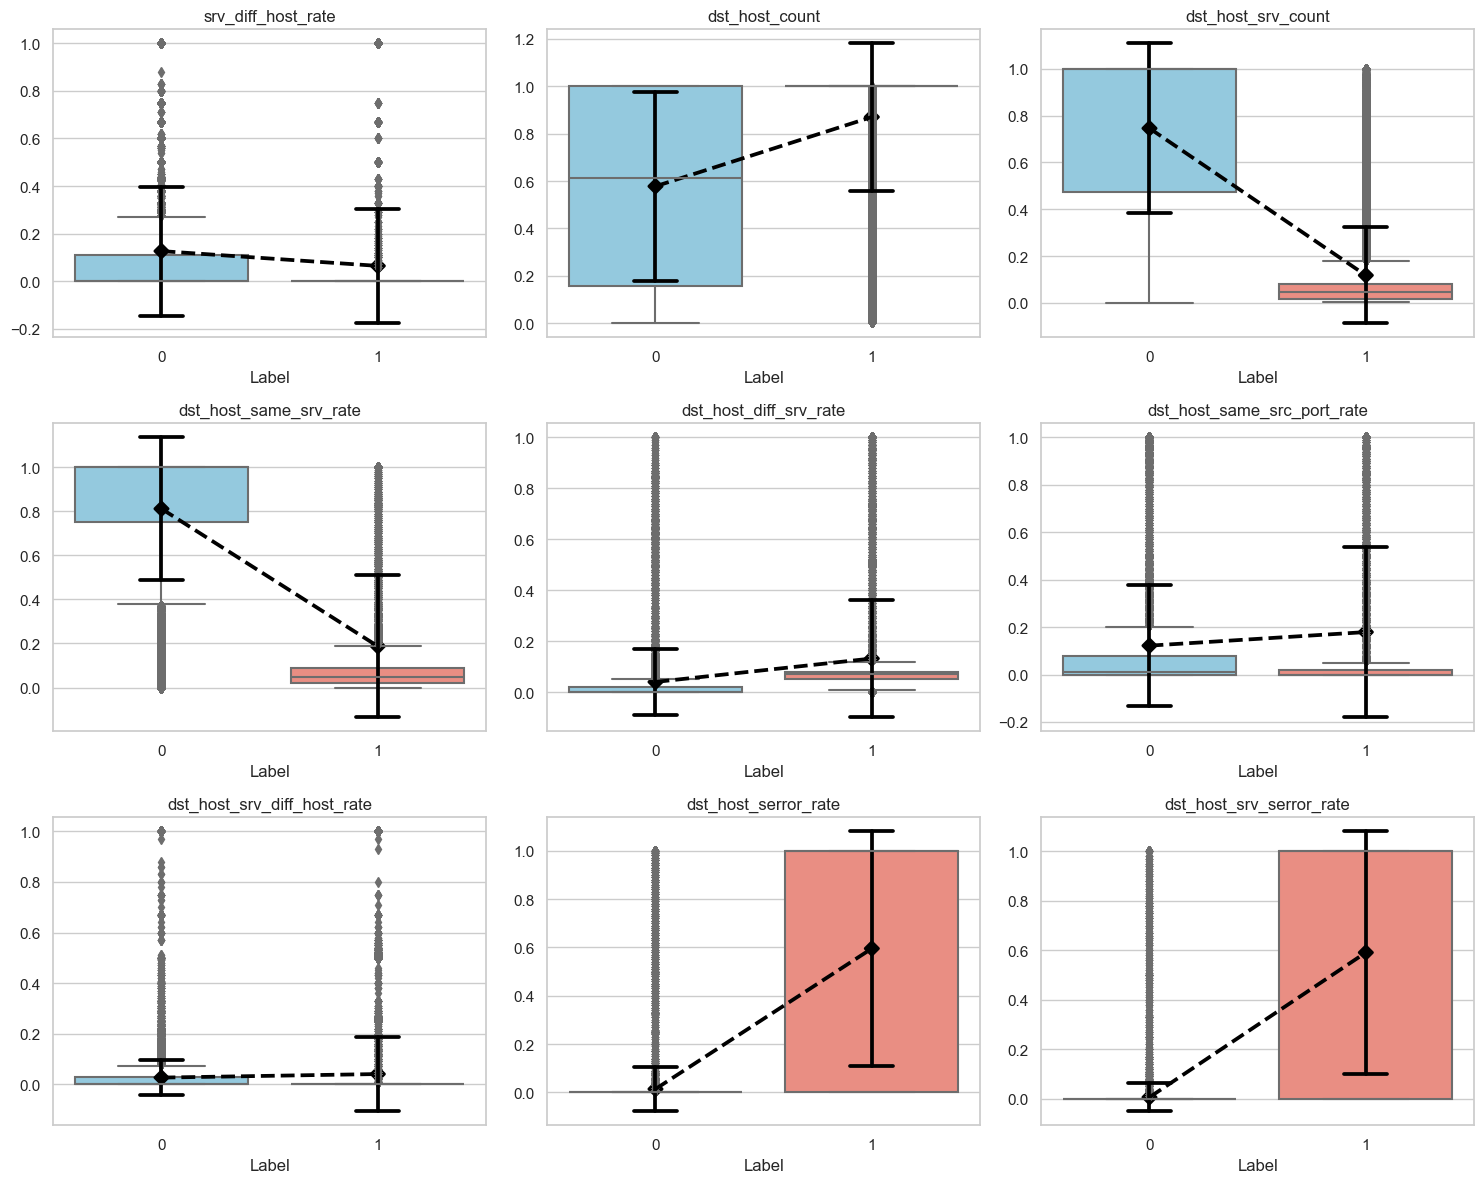

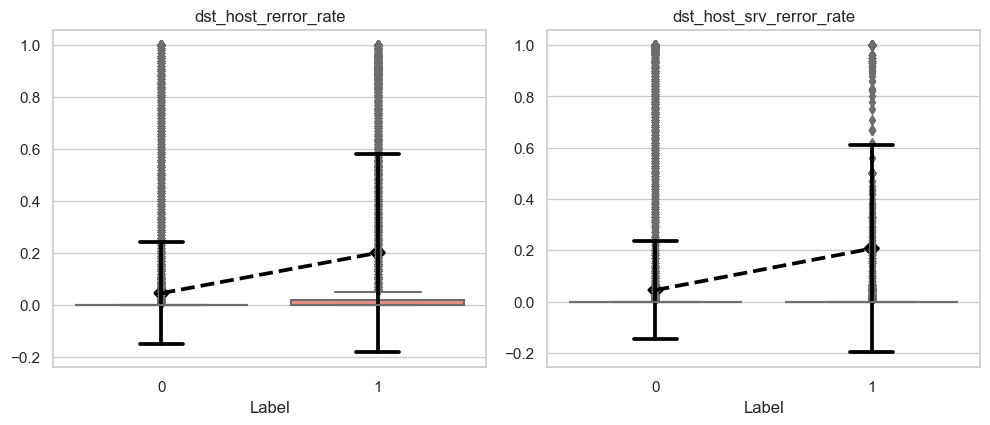

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set(style="whitegrid")

def plot_boxplots_in_grid(data, features, rows=3, cols=3):
    """
    Plot side-by-side boxplots with mean and std overlay in a grid.
    """
    num_plots = rows * cols
    for i in range(0, len(features), num_plots):
        subset = features[i:i+num_plots]

        fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*4))
        axes = axes.flatten()

        for j, col in enumerate(subset):
            sns.boxplot(
                data=data,
                x="label", y=col,
                palette={0: "skyblue", 1: "salmon"},
                ax=axes[j]
            )
            sns.pointplot(
                data=data,
                x="label", y=col,
                estimator=np.mean,
                errorbar=("sd"),  # standard deviation
                color="black",
                markers="D", linestyles="--", capsize=0.2,
                ax=axes[j]
            )
            axes[j].set_title(f"{col}", fontsize=12)
            axes[j].set_xlabel("Label")
            axes[j].set_ylabel("")

        # Hide any empty subplots if features < grid size
        for k in range(len(subset), len(axes)):
            fig.delaxes(axes[k])

        plt.tight_layout()
        plt.show()


# Call the function
plot_boxplots_in_grid(data, features, rows=3, cols=3)


In [105]:
x=data.drop(["label","difficulty"],axis=1)
y=data["label"]

In [106]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.5, random_state=0)
print(f'xtrain: {xtrain.shape} \nxtest: {xtest.shape} \nytrain: {ytrain.shape} \nytest: {ytest.shape}')

xtrain: (62986, 122) 
xtest: (62987, 122) 
ytrain: (62986,) 
ytest: (62987,)


In [107]:
xtrain

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
38531,0.000000,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
27768,0.000000,2.239189e-07,5.614772e-06,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
119507,0.000000,3.188489e-08,9.924138e-08,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4656,0.000000,1.673957e-07,5.838447e-06,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
50960,0.000000,1.543519e-07,1.594733e-06,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45891,0.000000,4.347940e-09,2.358891e-07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
117952,0.000000,2.123244e-07,3.829954e-06,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
42613,0.111424,7.246566e-10,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
43567,0.000000,8.369784e-07,2.931438e-07,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [108]:
ytrain

38531     1
27768     0
119507    0
4656      0
50960     0
         ..
45891     0
117952    0
42613     1
43567     0
68268     0
Name: label, Length: 62986, dtype: int64

In [109]:
xtest

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
11224,0.0,1.492793e-07,2.733718e-06,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
13951,0.0,1.731929e-07,1.709242e-06,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
62642,0.0,9.210386e-07,3.374207e-07,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
78373,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
22304,0.0,7.246566e-10,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82759,0.0,5.565363e-07,2.931438e-07,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
92164,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
95150,0.0,5.797253e-09,1.122191e-07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
91936,0.0,5.305211e-06,0.000000e+00,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [110]:
ytest

11224     0
13951     0
62642     0
78373     1
22304     1
         ..
82759     0
92164     1
95150     0
91936     0
102156    1
Name: label, Length: 62987, dtype: int64

In [111]:
from sklearn.linear_model import LogisticRegression
reg = 0.01
# train a logistic regression model on the training set
model = LogisticRegression(C=1/reg, solver="liblinear").fit(xtrain, ytrain)
print(model)

LogisticRegression(C=100.0, solver='liblinear')


In [112]:
predictions = model.predict(xtest)
print('Predicted labels: ', predictions)
print('Actual labels:    ' ,ytest)

Predicted labels:  [0 0 0 ... 0 0 1]
Actual labels:     11224     0
13951     0
62642     0
78373     1
22304     1
         ..
82759     0
92164     1
95150     0
91936     0
102156    1
Name: label, Length: 62987, dtype: int64


In [113]:
from sklearn.metrics import accuracy_score
print(f"Accuracy score: {accuracy_score(ytest, predictions)}")

Accuracy score: 0.9734230873037294


In [114]:
from sklearn.metrics import classification_report
print(classification_report(ytest, predictions))

              precision    recall  f1-score   support

           0       0.97      0.98      0.98     33579
           1       0.98      0.97      0.97     29408

    accuracy                           0.97     62987
   macro avg       0.97      0.97      0.97     62987
weighted avg       0.97      0.97      0.97     62987



In [115]:
from sklearn.metrics import precision_score, recall_score
print("Overall Precision:",precision_score(ytest, predictions))
print("Overall Recall:",recall_score(ytest, predictions))

Overall Precision: 0.9772836786673091
Overall Recall: 0.9655195865070729


In [116]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(ytest, predictions)
print (cm)

[[32919   660]
 [ 1014 28394]]


In [117]:
y_scores = model.predict_proba(xtest)
print(y_scores)

[[9.90981965e-01 9.01803451e-03]
 [9.88774578e-01 1.12254221e-02]
 [9.81718916e-01 1.82810843e-02]
 ...
 [9.83180337e-01 1.68196630e-02]
 [8.30527578e-01 1.69472422e-01]
 [1.79091321e-04 9.99820909e-01]]


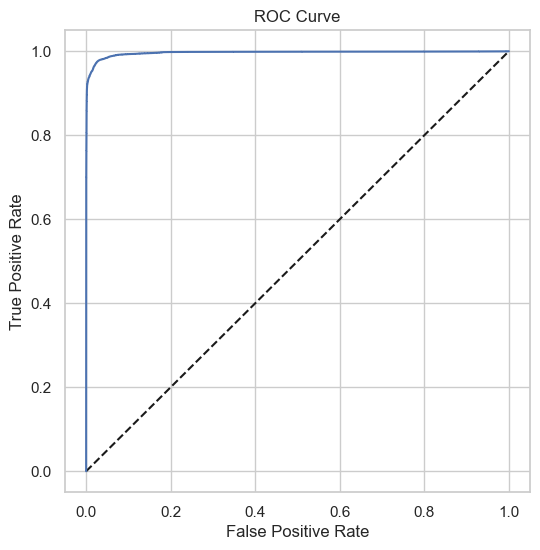

In [118]:
from sklearn.metrics import roc_curve
from sklearn.metrics import confusion_matrix

# calculate ROC curve
fpr, tpr, thresholds = roc_curve(ytest, y_scores[:,1])

# plot ROC curve
fig = plt.figure(figsize=(6, 6))
# Plot the diagonal 50% line
plt.plot([0, 1], [0, 1], 'k--')
# Plot the FPR and TPR achieved by our model
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

In [119]:
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(ytest,y_scores[:,1])
print('AUC: ' + str(auc))

AUC: 0.9962566827125002
